# important: to run the codes you need to use the following to download "project_transactions.csv" first and add it to the same folder as the codes. it was not uploaded to github due to large size (more than 100 Mb):
link (google drive): 
https://drive.google.com/file/d/1_OZE8eeWzCICsOnovZEGA4bOXGWxQNKT/view?usp=drive_link

# Final Project

Ok, so today we'll be working with the transactions, product, and hh_demographic tables in the project_data folder.

* First, read in the transactions data.

* Read in the only columns `household_key`, `BASKET_ID`, `DAY`, `PRODUCT_ID`, `QUANTITY`, and `SALES_VALUE`.

* Convert `DAY`, `QUANTITY`, and `PRODUCT_ID` to the smallest appropriate integer types.


# key objectives
- Read data from multiple csv files
- Explore data
- Join multiple data frames
- Filter, sort, aggregate data and summarize important information
- Work with datetime fileds and analyze time series
- Build plots to communicate key insights
- Optimize the import workflow
- Write out summary tables for stakeholders

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
sns.set_style("darkgrid")
pd.set_option('display.float_format', lambda x: '%.4f' % x) # to show numbers in the right format

In [2]:
transactions = pd.read_csv("project_transactions.csv", 
           usecols=["household_key", "BASKET_ID", "DAY", "PRODUCT_ID", "QUANTITY", "SALES_VALUE"],
           dtype={"DAY":"int16", "QUANTITY":"int32","PRODUDCT_ID":"int32"})

In [3]:
transactions.describe().round()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE
count,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000,2146311.0000
mean,1056.0000,34048967698.0000,390.0000,2884715.0000,101.0000,3.0000
std,605.0000,4723747572.0000,190.0000,3831949.0000,1152.0000,4.0000
min,1.0000,26984896261.0000,1.0000,25671.0000,0.0000,0.0000
25%,548.0000,30407979445.0000,229.0000,917231.0000,1.0000,1.0000
50%,1042.0000,32811761450.0000,392.0000,1027960.0000,1.0000,2.0000
75%,1581.0000,40128035453.0000,555.0000,1132771.0000,1.0000,3.0000
max,2099.0000,42305362535.0000,711.0000,18316298.0000,89638.0000,840.0000


In [4]:
transactions.info("deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2146311 entries, 0 to 2146310
Data columns (total 6 columns):
 #   Column         Dtype  
---  ------         -----  
 0   household_key  int64  
 1   BASKET_ID      int64  
 2   DAY            int16  
 3   PRODUCT_ID     int64  
 4   QUANTITY       int32  
 5   SALES_VALUE    float64
dtypes: float64(1), int16(1), int32(1), int64(3)
memory usage: 77.8 MB


In [5]:
# run following conde snippet to create a Date Column.

transactions = (
    transactions
    .assign(date = (pd.to_datetime("2016", format='%Y') 
                    + pd.to_timedelta(transactions["DAY"].sub(1).astype(str) + " days"))
           )
    .drop(["DAY"], axis=1)
)

In [6]:
transactions.head()

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,date
0,1364,26984896261,842930,1,2.1900,2016-01-01
1,1364,26984896261,897044,1,2.9900,2016-01-01
2,1364,26984896261,920955,1,3.0900,2016-01-01
3,1364,26984896261,937406,1,2.5000,2016-01-01
4,1364,26984896261,981760,1,0.6000,2016-01-01


## TIME BASED ANALYSIS

* Plot the sum of sales by month. Are sales growing over time?
* Next, plot the same series after filtering down to dates April 2016 and October 2017.
* Then, plot the sum of monthly sales in 2016 vs the monthly sales 2017.
* Finally, plot total sales by day of week.

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\2641977263.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  transactions.set_index("date").loc[:, "SALES_VALUE"].resample("M").sum().plot(color="#a9eb4e")


<Axes: xlabel='date'>

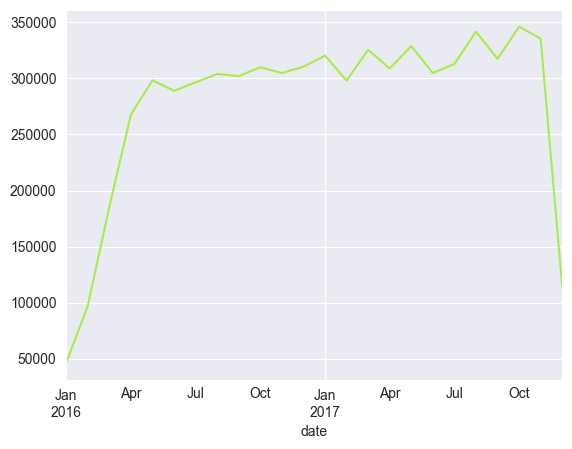

In [7]:
# setting date as index and use resample to calculate monthly sales
transactions.set_index("date").loc[:, "SALES_VALUE"].resample("M").sum().plot(color="#a9eb4e")

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\2542732278.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  transactions.set_index("date").sort_index().loc["2016-04":"2017-10", "SALES_VALUE"].resample("M").sum().plot(color="#a9eb4e")


<Axes: xlabel='date'>

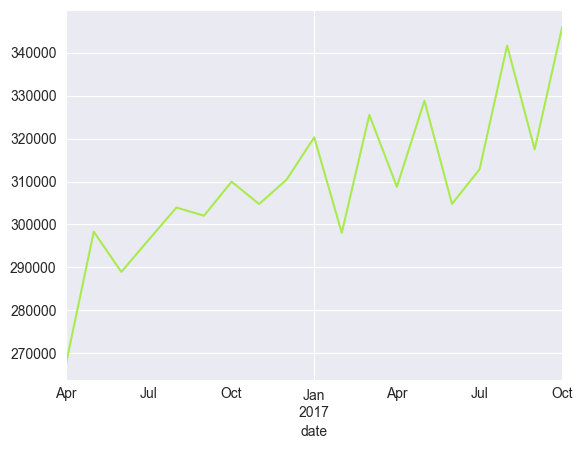

In [8]:
#transactions.head()
# the same plot from above with filtered dates fomr april 2016 - october 2017
transactions.set_index("date").sort_index().loc["2016-04":"2017-10", "SALES_VALUE"].resample("M").sum().plot(color="#a9eb4e")

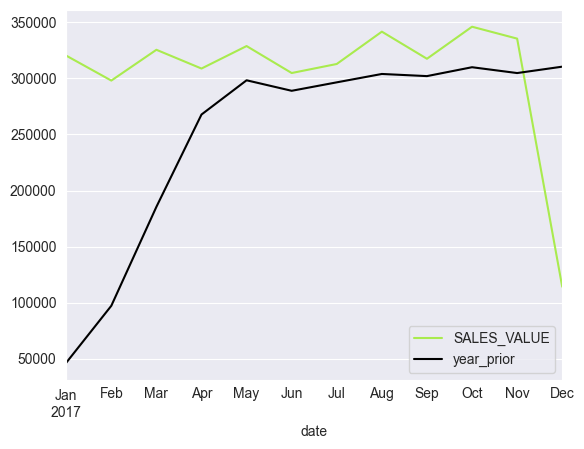

In [9]:
# plot the sum of monthly sales in 2016 vs the monthly sales in 2017 by creaing two columns
# which we could get using 2017 sales and shifted sales for 12 months
(transactions.set_index("date").resample("ME").sum().loc[:,["SALES_VALUE"]].assign(
    year_prior = lambda x: x["SALES_VALUE"].shift(12)
)).loc["2017"].plot(color=["#a9eb4e", "black"]);

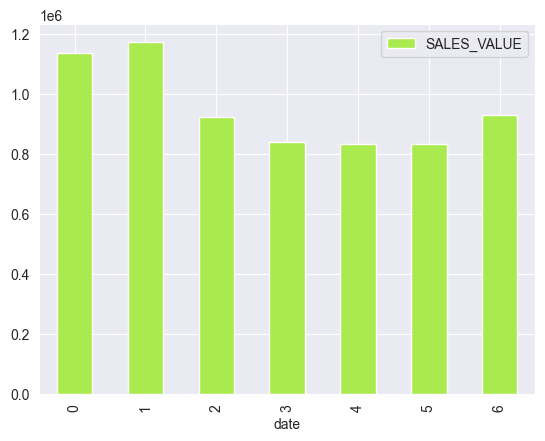

In [10]:
# plot total sales by day of week --> using groupby and bar chart
transactions.groupby(transactions["date"].dt.dayofweek).agg({"SALES_VALUE":"sum"}).plot.bar(color="#a9eb4e");

# DEMOGRAPHICS

* Read in the `hh_demographic.csv` file, but only the columns `AGE_DESC`, `INCOME_DESC`, `household_key`, and `HH_COMP_DESC`. Convert the appropriate columns to the category dtype.


* Then group the transactions table by household_id, and calculate the sum of SALES VALUE by household.


* Once you've done that, join the demographics DataFrame to the aggregated transactions table. Since we're interested in analyzing the demographic data we have, make sure not to include rows from transactions that don't match.


* Plot the sum of sales by age_desc and income_desc (in separate charts).


* Then, create a pivot table of the mean household sales by `AGE_DESC` and `HH_COMP_DESC`. Which of our demographics have the highest average sales?


In [11]:
demographics = pd.read_csv("hh_demographic.csv", usecols=["AGE_DESC", "INCOME_DESC", "household_key", "HH_COMP_DESC"],
                          dtype={"AGE_DESC":"category", "INCOME_DESC":"category", "HH_COMP_DESC":"category"})
demographics

,AGE_DESC,INCOME_DESC,HH_COMP_DESC,household_key
0,65+,35-49K,2 Adults No Kids,1
1,45-54,50-74K,2 Adults No Kids,7
2,25-34,25-34K,2 Adults Kids,8
3,25-34,75-99K,2 Adults Kids,13
4,45-54,50-74K,Single Female,16
...,...,...,...,...
796,35-44,50-74K,2 Adults No Kids,2494
797,45-54,75-99K,Unknown,2496
798,45-54,35-49K,Single Male,2497
799,25-34,50-74K,2 Adults No Kids,2498


In [12]:
demographics.info("deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   AGE_DESC       801 non-null    category
 1   INCOME_DESC    801 non-null    category
 2   HH_COMP_DESC   801 non-null    category
 3   household_key  801 non-null    int64   
dtypes: category(3), int64(1)
memory usage: 9.5 KB


In [13]:
demographics.describe()

,household_key
count,801.0000
mean,1235.1760
std,736.8046
min,1.0000
25%,596.0000
50%,1218.0000
75%,1914.0000
max,2499.0000


In [14]:
# grouping the transactions table by household_id, and calculate the sum of SALES VALUE by household
# and save the result in household_sales
household_sales = transactions.groupby("household_key").agg({"SALES_VALUE":"sum"})

In [15]:
# join the demographics DataFrame to the aggregated transactions table. 
# Since we're interested in analyzing the demographic data we have, make sure not to include rows from transactions that don't match.
# the common columns for both tables is household key, so we (inner) join the tables on that column
household_sales_demo = household_sales.merge(demographics, how="inner", left_on = "household_key", right_on = "household_key")

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\3607821053.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  household_sales_demo.groupby("AGE_DESC").agg({"SALES_VALUE":"sum"}).plot.bar(color="#a9eb4e", xlabel = "Age Group")


<Axes: xlabel='Age Group'>

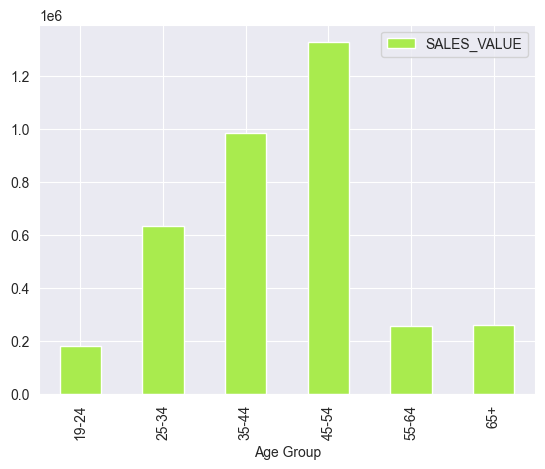

In [16]:
# Plotting the sum of sales by age group(AGE_DESC) and income (income_desc)
household_sales_demo.groupby("AGE_DESC").agg({"SALES_VALUE":"sum"}).plot.bar(color="#a9eb4e", xlabel = "Age Group")

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\2737279547.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  household_sales_demo.groupby("INCOME_DESC").agg({"SALES_VALUE":"sum"}).sort_values("SALES_VALUE", ascending = False).plot.bar(color="#a9eb4e", xlabel = "Income Group")


<Axes: xlabel='Income Group'>

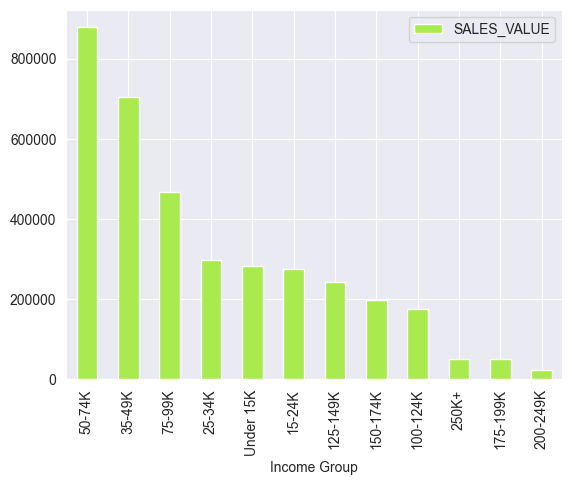

In [17]:
household_sales_demo.groupby("INCOME_DESC").agg({"SALES_VALUE":"sum"}).sort_values("SALES_VALUE", ascending = False).plot.bar(color="#a9eb4e", xlabel = "Income Group")

In [18]:
# create a pivot table of the mean household sales by `AGE_DESC` and `HH_COMP_DESC`. 
household_sales_demo.pivot_table(
    index = "AGE_DESC",
    columns= "HH_COMP_DESC",
    values = "SALES_VALUE",
    aggfunc= "mean", # method
    margins = True # for totals
)

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\2147514373.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  household_sales_demo.pivot_table(


HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown,All
AGE_DESC,,,,,,,
19-24,7268.7967,5428.9450,4020.8000,4576.0956,3216.8350,4911.2750,4692.0777
25-34,5512.1969,5753.9735,5638.5158,4807.4406,4909.5224,7356.2700,5435.5175
35-44,6297.7378,6691.7723,6260.4124,6015.1921,4844.1920,4227.6918,6090.5567
45-54,6632.5692,6610.4845,5839.5270,4549.3654,4636.6371,4843.9957,5534.8800
55-64,3064.8700,4695.6550,5752.4137,4816.1485,3922.5463,7973.7500,5168.9242
65+,4040.8100,5536.8667,4614.1086,4059.6994,3871.5560,2879.2900,4340.9365
All,6032.8021,6280.0691,5599.8578,4895.9284,4544.6467,4936.1278,5468.3987


In [19]:
# Which of our demographics have the highest average sales? --> to answer Ied could use heatemap
household_sales_demo.pivot_table(
    index = "AGE_DESC",
    columns= "HH_COMP_DESC",
    values = "SALES_VALUE",
    aggfunc= "mean", # method
    margins = True # for totals
).style.background_gradient(cmap="RdYlGn", axis = None)

# single males spend the least
# kids are high spenders

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\1359356990.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  household_sales_demo.pivot_table(


HH_COMP_DESC,1 Adult Kids,2 Adults Kids,2 Adults No Kids,Single Female,Single Male,Unknown,All
AGE_DESC,,,,,,,
19-24,7268.796667,5428.945000,4020.800000,4576.095556,3216.835000,4911.275000,4692.077692
25-34,5512.196875,5753.973514,5638.515833,4807.440588,4909.522381,7356.270000,5435.517521
35-44,6297.737778,6691.772264,6260.412444,6015.192069,4844.192000,4227.691818,6090.556728
45-54,6632.569167,6610.484490,5839.527027,4549.365405,4636.637083,4843.995682,5534.879958
55-64,3064.870000,4695.655000,5752.413684,4816.148462,3922.546250,7973.750000,5168.924200
65+,4040.810000,5536.866667,4614.108571,4059.699412,3871.556000,2879.290000,4340.936500
All,6032.802143,6280.069103,5599.857756,4895.928361,4544.646750,4936.127778,5468.398743


# PRODUCT DEMOGRAPHICS

* Read in the product csv file.

* Only read in product_id and department from product (consider converting columns).

* Join the product DataFrame to transactions and demographics tables, performing an inner join when joining both tables.

* Finally, pivot the fully joined dataframe by AGE_DESC and DEPARTMENT, calculating the sum of sales. Which category does our youngest demographic perform well in?



In [20]:
product = pd.read_csv("product.csv", usecols= ["PRODUCT_ID", "DEPARTMENT"], dtype={"PRODUCT_ID":"int32", "DEPARTMENT":"category"})

In [21]:
product.describe()

,PRODUCT_ID
count,92353.0000
mean,5328352.8369
std,5359937.0780
min,25671.0000
25%,970628.0000
50%,1621091.0000
75%,9704770.0000
max,18316298.0000


In [22]:
# join transactions, product and demographocs on their common columns
trans_demo_prod = (transactions.
 merge(demographics, how="inner", left_on="household_key" ,right_on="household_key").
 merge(product, how="inner", left_on="PRODUCT_ID" ,right_on="PRODUCT_ID")
)
trans_demo_prod.head(2)

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,date,AGE_DESC,INCOME_DESC,HH_COMP_DESC,DEPARTMENT
0,1364,26984896261,842930,1,2.1900,2016-01-01,65+,100-124K,Single Female,GROCERY
1,1364,26984896261,897044,1,2.9900,2016-01-01,65+,100-124K,Single Female,GROCERY


In [23]:
trans_demo_prod.info("deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1161575 entries, 0 to 1161574
Data columns (total 10 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   household_key  1161575 non-null  int64         
 1   BASKET_ID      1161575 non-null  int64         
 2   PRODUCT_ID     1161575 non-null  int64         
 3   QUANTITY       1161575 non-null  int32         
 4   SALES_VALUE    1161575 non-null  float64       
 5   date           1161575 non-null  datetime64[ns]
 6   AGE_DESC       1161575 non-null  category      
 7   INCOME_DESC    1161575 non-null  category      
 8   HH_COMP_DESC   1161575 non-null  category      
 9   DEPARTMENT     1161575 non-null  category      
dtypes: category(4), datetime64[ns](1), float64(1), int32(1), int64(3)
memory usage: 53.2 MB


In [24]:
# Finally, pivot the fully joined dataframe by AGE_DESC and DEPARTMENT, 
# calculating the sum of sales. Which category does our youngest demographic perform well in?
trans_demo_prod.pivot_table(
    index ="DEPARTMENT",
    columns=  "AGE_DESC",
    values= "SALES_VALUE",
    aggfunc="sum",
)

# Which category does our youngest demographic perform well in? spirits

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\4150520830.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  trans_demo_prod.pivot_table(


AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+
DEPARTMENT,,,,,,
,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
AUTOMOTIVE,11.6400,21.2500,72.5800,55.9200,0.0000,16.3700
CHARITABLE CONT,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
CHEF SHOPPE,81.3000,134.1600,348.5300,418.2400,80.8600,149.2400
CNTRL/STORE SUP,2.0000,0.0000,1.0000,9.9500,2.0000,0.1000
COSMETICS,698.6300,2273.0300,4362.0200,5187.5700,986.2600,600.9000
COUP/STR & MFG,7.4900,48.4200,121.2000,154.5500,40.6800,20.4900
DAIRY DELI,3.8000,3.8500,7.3900,16.7500,3.1400,1.9400
DELI,4043.3000,18181.9400,34577.2900,44334.2200,9850.5400,10462.3300


In [25]:
# creating heatmap to answer the question
trans_demo_prod.pivot_table(
    index ="DEPARTMENT",
    columns=  "AGE_DESC",
    values= "SALES_VALUE",
    aggfunc="sum",
).style.background_gradient(cmap="RdYlGn", axis = 1) 
# Which category does our youngest demographic perform well in? SPIRITS

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\3274219629.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  trans_demo_prod.pivot_table(


AGE_DESC,19-24,25-34,35-44,45-54,55-64,65+
DEPARTMENT,,,,,,
,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AUTOMOTIVE,11.640000,21.250000,72.580000,55.920000,0.000000,16.370000
CHARITABLE CONT,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CHEF SHOPPE,81.300000,134.160000,348.530000,418.240000,80.860000,149.240000
CNTRL/STORE SUP,2.000000,0.000000,1.000000,9.950000,2.000000,0.100000
COSMETICS,698.630000,2273.030000,4362.020000,5187.570000,986.260000,600.900000
COUP/STR & MFG,7.490000,48.420000,121.200000,154.550000,40.680000,20.490000
DAIRY DELI,3.800000,3.850000,7.390000,16.750000,3.140000,1.940000
DELI,4043.300000,18181.940000,34577.290000,44334.220000,9850.540000,10462.330000


# EXPORT

Finally, export your pivot table to an excel file. Make sure to provide a sheet name.

In [26]:
trans_demo_prod.pivot_table(
    index ="DEPARTMENT",
    columns=  "AGE_DESC",
    values= "SALES_VALUE",
    aggfunc="sum",
).style.background_gradient(cmap="RdYlGn", axis = 1).to_excel("demographic_category_sales.xlsx", sheet_name="sales_pivot")

C:\Users\sasan\AppData\Local\Temp\ipykernel_22052\1028746364.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  trans_demo_prod.pivot_table(
